## Plot of baselines



In [1]:
# -----------------------------
# Baseline (Test Phase) data
# -----------------------------
baselines_order = [
    ("10-percentile", 31140187.49, 11204418.18),
    ("25-percentile",  8866932.39, 13638230.82),
    ("50-percentile",   701161.83, 17645590.39),
    ("60-percentile",   256969.73, 19022590.67),
    ("70-percentile",   113307.50, 20221244.13),
    ("80-percentile",    40573.39, 21633983.58),
    ("90-percentile",    21460.62, 22796113.69),
    ("95-percentile",    17332.36, 23473034.11),
    ("97-percentile",    14969.60, 23984053.75),
    ("FCFS",             12474.55, 24747898.11),
]


# -----------------------------
# Model seed-level data
# -----------------------------
models_raw = {
    "η=1 (dense)": {
        "waits":  [10511, 19251, 12614, 11575, 11762],
        "carbons":[24977084, 25063805, 25111206, 24961711, 24796468],
    },
    "η=1 (sparse)": {
        "waits":  [11643, 21504, 866688, 12303, 1810477],
        "carbons":[24849969, 25013930, 28238783, 24555615, 29393504],
    },
}


## Run best waittime dense

In [2]:
from src.analysis import (
    evaluate_models,
    evaluate_baselines,
    wait_time_distributions_vs_baseline,
    plot_wait_time_distributions_for_seeds,
    plot_wait_time_boxplots_for_seeds,
    build_wait_size_heatmap_for_seed,
    build_wait_size_heatmap_for_fcfs,
    build_wait_size_heatmaps_for_seed_vs_fcfs,
    plot_wait_size_heatmaps,
)
from src.metrics import collect_wait_times
from src.viz_style import use_house_style
import numpy as np

use_house_style()

train_and_eval_folder = "results/train_and_eval/eta1_optimal/user_ci_disabled/eta_1"
seeds = [1]

model_eval = evaluate_models(
    train_eval_dir=train_and_eval_folder,
    seeds=seeds,
    mode="test",
    n_eval_episodes=1,
)

baseline_eval = evaluate_baselines(
    train_eval_dir=train_and_eval_folder,
    mode="test",
    n_eval_episodes=1,
    include_percentiles=False,
)


Current secounds after start:  1974258
2669
Current secounds after start:  3909739
5064
Current secounds after start:  6184375
7556
Current secounds after start:  8794357
10299
Current secounds after start:  11046166
12844
Current secounds after start:  13257160
15201
Current secounds after start:  15449946
17759
Current secounds after start:  17345015
20059
Executing baseline:  FCFS Baseline
Episode  0
Current secounds after start:  2532338
3335
Current secounds after start:  5572999
6767
Current secounds after start:  8771844
10253
Current secounds after start:  11867331
13627
Current secounds after start:  14909089
17113
Current secounds after start:  17461067
20446


In [3]:
def _collect_waits(raw_stats: dict[str, dict[str, list]], key: str) -> list[float]:
    waits: list[float] = []
    for history in raw_stats[key]["job_scheduled_history"]:
        waits.extend(collect_wait_times(history))
    return waits

waits_model: list[float] = []
for seed_stats in model_eval.values():
    waits_model.extend(_collect_waits(seed_stats["raw"], "model"))

waits_baseline = _collect_waits(baseline_eval["raw"], "FCFS Baseline")

positive_samples = [w for w in waits_model + waits_baseline if w > 0]
if positive_samples:
    upper_clip = float(np.percentile(positive_samples, 99))
    value_range = (0.0, upper_clip)
else:
    value_range = None

value_range


(0.0, 285159.64000000234)

In [4]:
distributions = wait_time_distributions_vs_baseline(
    train_eval_dir=train_and_eval_folder,
    model_stats=model_eval,
    baseline_raw_stats=baseline_eval["raw"],
    baseline_key="FCFS Baseline",
    bins="fd",
    normalize=True,
    value_range=value_range,
)


In [5]:
seed, distribution = next(iter(distributions.items()))
distribution['model']['summary'], distribution['FCFS Baseline']['summary']


({'count': 22341,
  'mean': 10511.272592990466,
  'median': 0.0,
  'min': 0.0,
  'max': 1532152.0,
  'p90': 20313.0,
  'p95': 45615.0,
  'zero_fraction': 0.5881115437983976},
 {'count': 22341,
  'mean': 12474.54858779822,
  'median': 0.0,
  'min': 0.0,
  'max': 732464.0,
  'p90': 40116.0,
  'p95': 74055.0,
  'zero_fraction': 0.604091132894678})

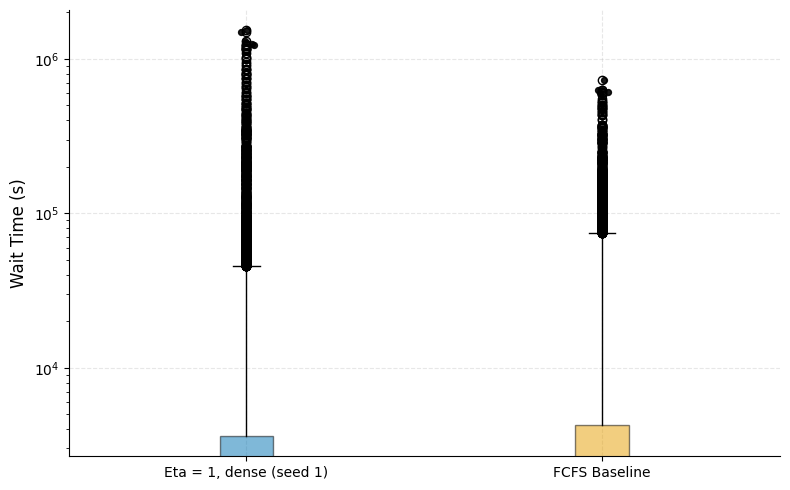

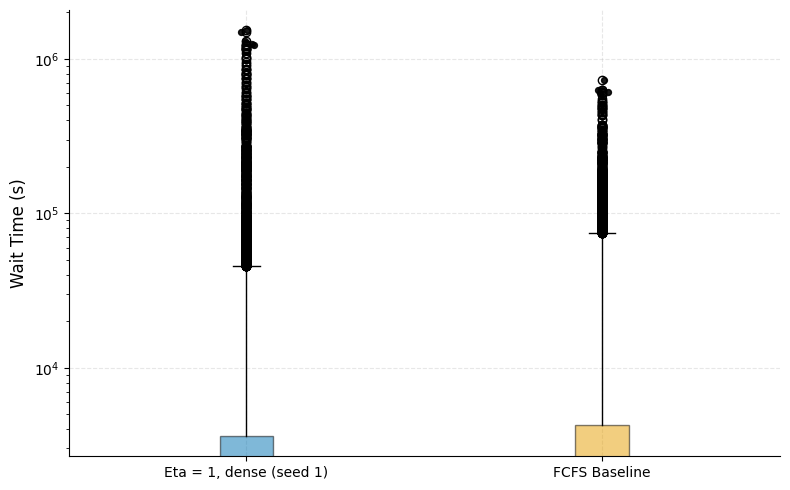

In [6]:
ax_box = plot_wait_time_boxplots_for_seeds(
    train_eval_dir=train_and_eval_folder,
    distributions=distributions,
    baseline_key="FCFS Baseline",
    baseline_label="FCFS Baseline",
    model_label="Eta = 1, dense",
    figsize=(8.0, 5.0),
    whis=(5, 95),
    showfliers=True,
    log_scale=True,
    show=False,
)
ax_box.figure


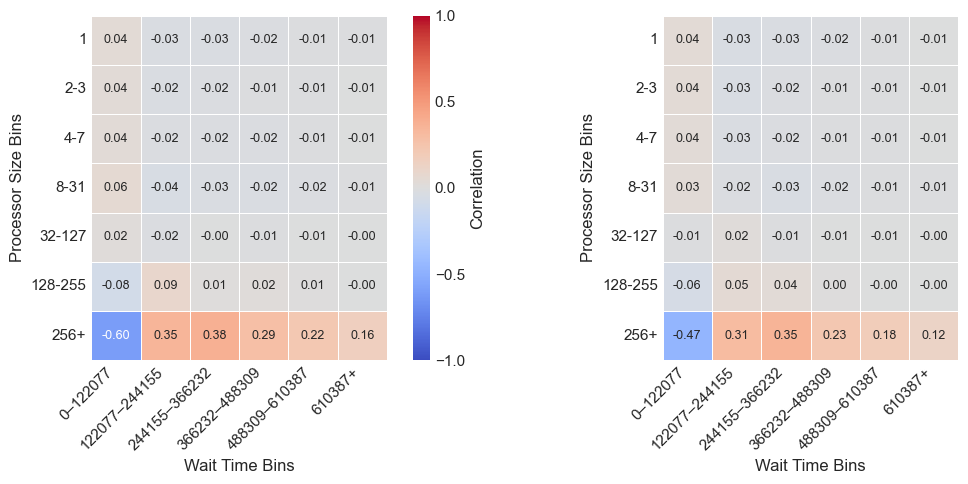

In [7]:
hm_model, hm_fcfs = build_wait_size_heatmaps_for_seed_vs_fcfs(
    train_eval_dir=train_and_eval_folder,
    model_eval=model_eval,
    baseline_eval=baseline_eval,
    seed=1,
    size_metric="procs",
    x_bins=40,
    y_bins="fd",
    density=False,
)
axes_heatmap = plot_wait_size_heatmaps(
    [hm_model, hm_fcfs],
    labels=None,
    share_colorbar=True,
    show=False,
)


/Users/mikkeldahl/green-hpc-scheduler/src/validation.py:1127: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.savefig(png_path, dpi=150)
/Users/mikkeldahl/green-hpc-scheduler/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


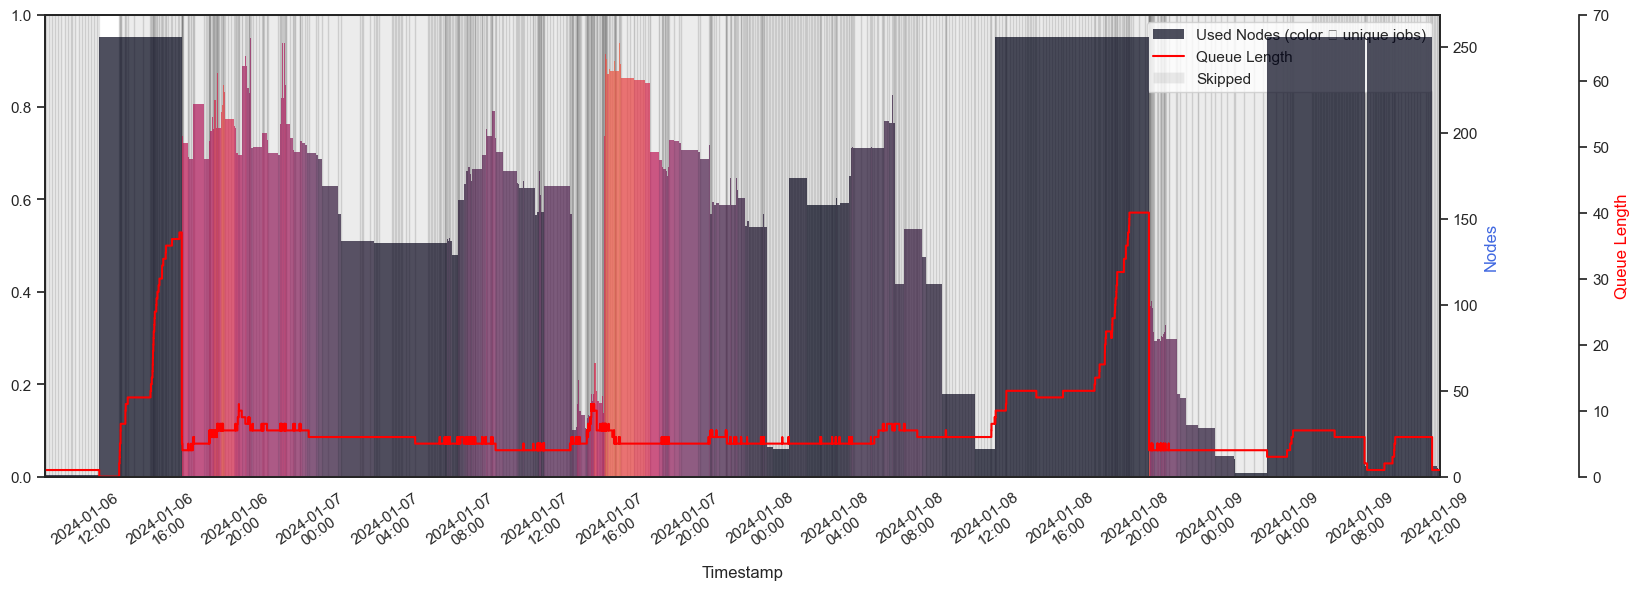

('renderings/seed_3_eta_0.5.png', <Figure size 1800x600 with 3 Axes>)

/Users/mikkeldahl/green-hpc-scheduler/.venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  func(*args, **kwargs)


In [30]:
from src.validation import Validation
val = Validation()
val.load_dir(model_dir=train_and_eval_folder)
val.render_timeseries_plot(model_eval[1]["raw"]['model']['action_traces'], start_time = 3600*24*5.4, end_time = 3600*24*8.5, name = "seed_3_eta_0.5",  display_carbon_itensity=False, max_queue_length=70)

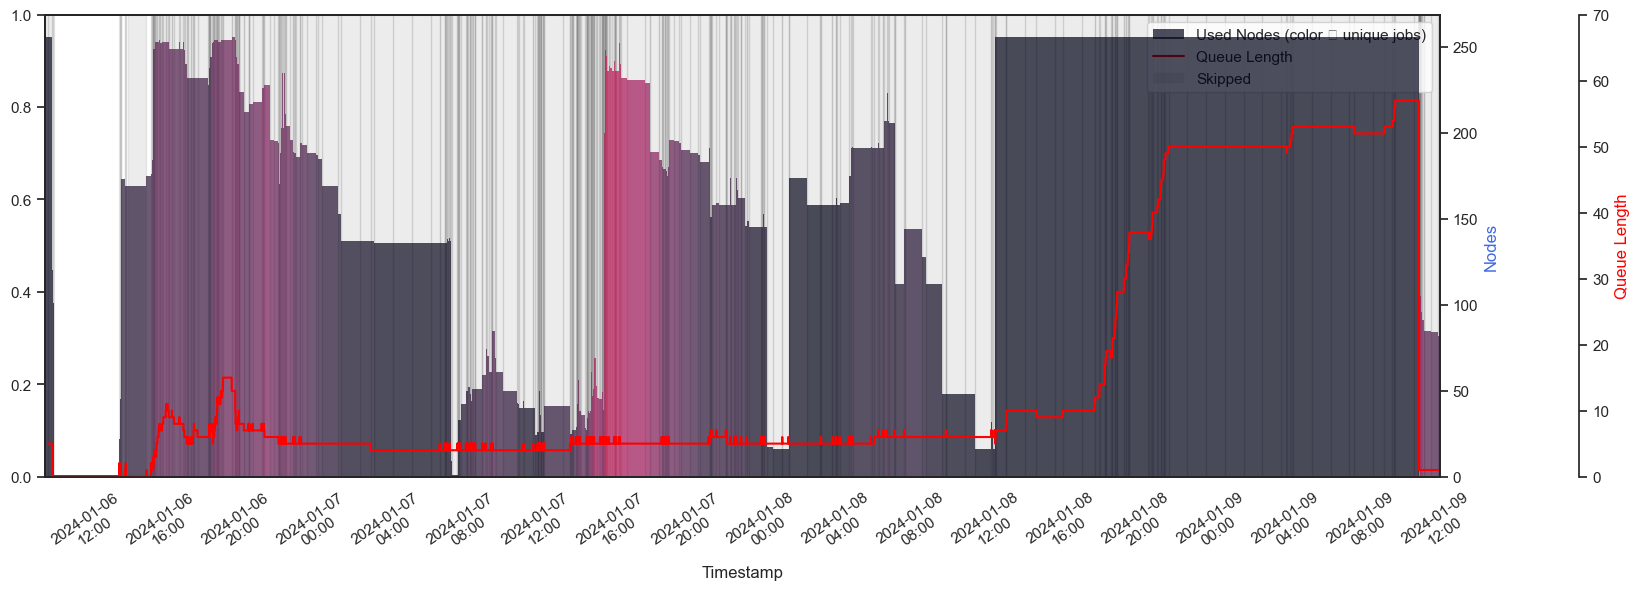

('renderings/seed_3_eta_0.5.png', <Figure size 1800x600 with 3 Axes>)

In [31]:
val.render_timeseries_plot(baseline_eval["raw"]['FCFS Baseline']['action_traces'], start_time = 3600*24*5.4, end_time = 3600*24*8.5, name = "seed_3_eta_0.5",display_carbon_itensity=False, max_queue_length=70)